In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    ReLU,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
train_df = pd.read_csv("../dataset/train_split.csv")
val_df = pd.read_csv("../dataset/val_split.csv")

class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

print("Jumlah training   :", len(train_df))
print("Jumlah validation :", len(val_df))

Jumlah training   : 21947
Jumlah validation : 5487


In [4]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=1
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = image / 255.0

    return image, label

In [5]:
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label_index"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label_index"].values
    )
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(
    len(train_df),
    seed=42
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

In [6]:
images, labels = next(iter(train_dataset))

print("Shape images :", images.shape)
print("Shape labels :", labels.shape)
print("Pixel min    :", tf.reduce_min(images).numpy())
print("Pixel max    :", tf.reduce_max(images).numpy())

Shape images : (32, 48, 48, 1)
Shape labels : (32,)
Pixel min    : 0.0
Pixel max    : 1.0


In [7]:
model = Sequential([
    Input(shape=(48, 48, 1)),

    # Block 1
    Conv2D(32, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    Conv2D(32, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    Conv2D(64, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    Conv2D(128, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Classifier
    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(7, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 12, 12, 128)    │             

 Total params: 305,639 (1.17 MB)

 Trainable params: 304,743 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20


d:\JamTerbang\DL\KlasifikasiEkspresi\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


686/686 ━━━━━━━━━━━━━━━━━━━━ 107s 143ms/step - accuracy: 0.2696 - loss: 1.7704 - val_accuracy: 0.2588 - val_loss: 1.7390
Epoch 2/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 103s 144ms/step - accuracy: 0.3780 - loss: 1.5776 - val_accuracy: 0.4266 - val_loss: 1.4500
Epoch 3/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 106s 149ms/step - accuracy: 0.4390 - loss: 1.4529 - val_accuracy: 0.4066 - val_loss: 1.4945
Epoch 4/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 106s 149ms/step - accuracy: 0.4657 - loss: 1.3910 - val_accuracy: 0.4587 - val_loss: 1.3994
Epoch 5/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 109s 153ms/step - accuracy: 0.4872 - loss: 1.3440 - val_accuracy: 0.4208 - val_loss: 1.4945
Epoch 6/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 113s 158ms/step - accuracy: 0.5011 - loss: 1.3142 - val_accuracy: 0.4779 - val_loss: 1.3634
Epoch 7/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 108s 151ms/step - accuracy: 0.5146 - loss: 1.2771 - val_accuracy: 0.4553 - val_loss: 1.4338
Epoch 8/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 98s 138ms/step - accuracy: 0.5279 - loss: 1.243

In [10]:
y_true_improved = []
y_pred_improved = []

for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_improved.extend(labels.numpy())
    y_pred_improved.extend(predicted_labels)

y_true_improved = np.array(y_true_improved)
y_pred_improved = np.array(y_pred_improved)

print("Jumlah data validation:", len(y_true_improved))

Jumlah data validation: 5487


In [11]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_improved,
        y_pred_improved,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       angry       0.63      0.30      0.40       767
     disgust       0.00      0.00      0.00        76
        fear       0.44      0.23      0.30       777
       happy       0.61      0.95      0.74      1417
     neutral       0.55      0.50      0.52       973
         sad       0.44      0.58      0.50       943
    surprise       0.74      0.58      0.65       534

    accuracy                           0.56      5487
   macro avg       0.49      0.45      0.45      5487
weighted avg       0.55      0.56      0.53      5487



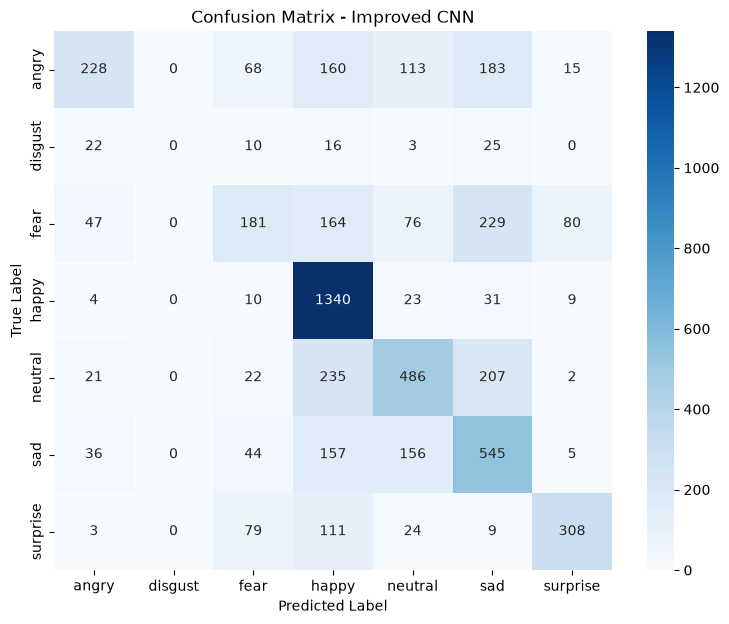

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_improved = confusion_matrix(
    y_true_improved,
    y_pred_improved
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_improved,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Improved CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [14]:
checkpoint = ModelCheckpoint(
    "../models/improved_cnn_best.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [15]:
tf.keras.backend.clear_session()

In [16]:
model = Sequential([
    Input(shape=(48, 48, 1)),

    # Block 1
    Conv2D(32, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    Conv2D(32, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    Conv2D(64, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    Conv2D(128, (3, 3), padding="same"),
    BatchNormalization(),
    ReLU(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Classifier
    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(7, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 12, 12, 128)    │             

 Total params: 305,639 (1.17 MB)

 Trainable params: 304,743 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
history_final = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[
        checkpoint,
        early_stopping
    ]
)

Epoch 1/20


d:\JamTerbang\DL\KlasifikasiEkspresi\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.2558 - loss: 1.7960
Epoch 1: val_accuracy improved from None to 0.22599, saving model to ../models/improved_cnn_best.keras

Epoch 1: finished saving model to ../models/improved_cnn_best.keras
686/686 ━━━━━━━━━━━━━━━━━━━━ 99s 132ms/step - accuracy: 0.2558 - loss: 1.7960 - val_accuracy: 0.2260 - val_loss: 1.7798
Epoch 2/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.3507 - loss: 1.6305
Epoch 2: val_accuracy improved from 0.22599 to 0.26754, saving model to ../models/improved_cnn_best.keras

Epoch 2: finished saving model to ../models/improved_cnn_best.keras
686/686 ━━━━━━━━━━━━━━━━━━━━ 93s 130ms/step - accuracy: 0.3507 - loss: 1.6305 - val_accuracy: 0.2675 - val_loss: 1.7626
Epoch 3/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.4202 - loss: 1.4885
Epoch 3: val_accuracy improved from 0.26754 to 0.37434, saving model to ../models/improved_cnn_best.keras

Epoch 3: finished saving model to ../models/improved_

In [19]:
import os

model_path = "../models/improved_cnn_best.keras"

print("Model tersimpan:", os.path.exists(model_path))
print("Lokasi:", model_path)

Model tersimpan: True
Lokasi: ../models/improved_cnn_best.keras


In [25]:
best_model = tf.keras.models.load_model(
    "../models/improved_cnn_best.keras"
)

print("Best model berhasil dimuat.")

Best model berhasil dimuat.


In [35]:
# %%
TEST_DIR = "../dataset/processed/test"

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    color_mode="grayscale",
    image_size=(48, 48),
    batch_size=32,
    shuffle=False
)

test_dataset = test_dataset.map(
    lambda images, labels: (
        tf.cast(images, tf.float32) / 255.0,
        labels
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

images, labels = next(iter(test_dataset))

print("Shape images :", images.shape)
print("Shape labels :", labels.shape)
print("Dtype        :", images.dtype)
print("Pixel min    :", tf.reduce_min(images).numpy())
print("Pixel max    :", tf.reduce_max(images).numpy())

Found 6559 files belonging to 7 classes.
Shape images : (32, 48, 48, 1)
Shape labels : (32,)
Dtype        : <dtype: 'float32'>
Pixel min    : 0.0
Pixel max    : 1.0


In [36]:
test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.5705 - loss: 1.1350
Test Loss     : 1.1349622011184692
Test Accuracy : 0.5705137848854065


In [37]:
y_true_test = []
y_pred_test = []

for images, labels in test_dataset:
    predictions = best_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_test.extend(labels.numpy())
    y_pred_test.extend(predicted_labels)

y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)

print("Jumlah data test:", len(y_true_test))

Jumlah data test: 6559


In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_test,
        y_pred_test,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       angry       0.48      0.52      0.50       887
     disgust       0.00      0.00      0.00        79
        fear       0.32      0.23      0.27       922
       happy       0.77      0.87      0.81      1710
     neutral       0.59      0.46      0.52      1182
         sad       0.46      0.50      0.48      1198
    surprise       0.57      0.76      0.65       581

    accuracy                           0.57      6559
   macro avg       0.46      0.48      0.46      6559
weighted avg       0.55      0.57      0.56      6559



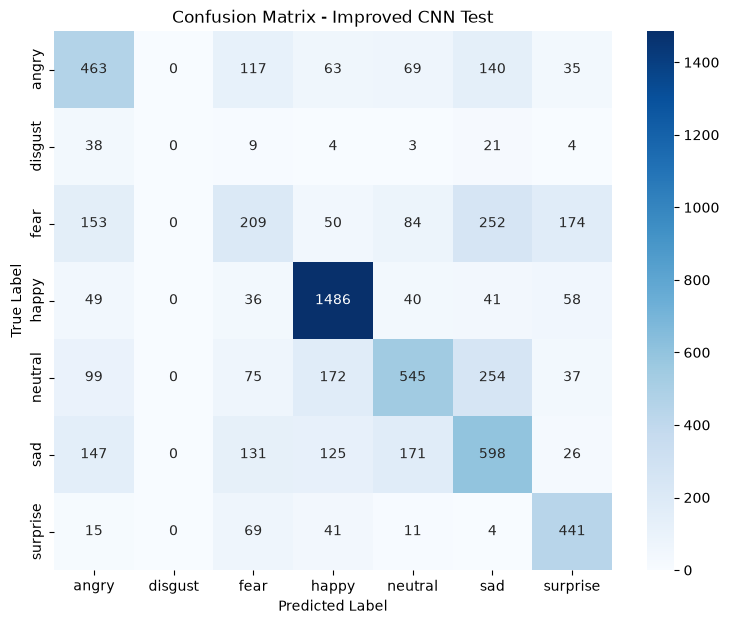

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_test = confusion_matrix(
    y_true_test,
    y_pred_test
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Improved CNN Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()